# Getting started with MemsArrayWS objects

The `MemsArrayWS` class allows getting signals from a remote antenna running a local *Megamicros Broadcast Server (MBS)* server. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from megamicros.log import log
from megamicros.core.ws import MemsArrayWS

log.setLevel( "INFO" )

# Set server access credentials
#HOST = 'buzenval20.fr'
#HOST = 'parisparc.biimea.tech
HOST = 'localhost'
PORT = 9002

## Connecting to the remote server

Providing a *MBS* server is running at ``HOST:PORT``, one can try to connect by creating a ``MemsArrayWS`` object.

In [2]:
# Define the antenna
try:
    antenna = MemsArrayWS( HOST, port=PORT )
except Exception as e:
    print( f"Failed: {e}" )


2023-11-06 14:07:18,694 [INFO]:  .Install MemsArrayWS settings
2023-11-06 14:07:18,696 [INFO]:  .Created a new antenna
2023-11-06 14:07:18,697 [INFO]:  .Async event loop already running. Adding coroutine to the event loop...


2023-11-06 14:07:18,700 [INFO]:  .Try connecting to ws://localhost:9002...
2023-11-06 14:07:18,717 [INFO]:  .Received positive answer from server
2023-11-06 14:07:18,718 [INFO]:  .Getting settings values from remote receiver...
2023-11-06 14:07:18,719 [INFO]:  .Received settings from server [ok]
2023-11-06 14:07:18,720 [INFO]:  .Set 32 available MEMs numbered from 0 to 31
2023-11-06 14:07:18,720 [INFO]:  .No analogic channels available
2023-11-06 14:07:18,722 [INFO]:  .Starting MegamicrosWS device [ready]


## Getting remote settings

By using the `settings` command, you can get the settings of the remote antenna:

In [3]:
# Perform an antenna settings
antenna.settings()

# Print some results
print( f"Available mems: {antenna.available_mems}" )
print( f"Available analogs: {antenna.available_analogs}" )
print( f"Default sampling freequency: {antenna.sampling_frequency} Hz" )

Available mems: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Available analogs: []
Default sampling freequency: 50000 Hz


2023-11-06 14:07:22,062 [INFO]:  .Connecting to remote host localhost:9002...
2023-11-06 14:07:22,064 [INFO]:  .Connected
2023-11-06 14:07:22,065 [INFO]:  .Send settings command to server
2023-11-06 14:07:22,066 [INFO]:  .Remote server settings command successfull
2023-11-06 14:07:22,067 [INFO]:  .Install MemsArray settings
2023-11-06 14:07:22,067 [INFO]:  .Set datatype to int32 
2023-11-06 14:07:22,068 [INFO]:  .Install MemsArrayWS settings
2023-11-06 14:07:22,068 [INFO]:  .New settings:
2023-11-06 14:07:22,068 [INFO]:   > available_mems: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
2023-11-06 14:07:22,069 [INFO]:   > available_analogs: []
2023-11-06 14:07:22,069 [INFO]:   > datatype: int32
2023-11-06 14:07:22,070 [INFO]:   > frame_length: 256
2023-11-06 14:07:22,070 [INFO]:   > mems_sensibility: 7.539965556205927e-06
2023-11-06 14:07:22,070 [INFO]:   > sampling_frequency: 50000.0 Hz
2023-11-06 14:07:22,071 [INF

## Performing a selftest

It may be a good idea to run a *selftest* of the remote antenna before getting settings.
Indeed, the antenna could have been chanded or modified since the last request. 
IOn addition, when performing a `selftest()`, new settings values are sent as response of the request so that you do not have to send a new `settings()` request.

In [ ]:
# Perform an antenna selftest
antenna.selftest()

# getting some antenna settings
print( f"Available mems: {antenna.available_mems}" )
print( f"Available analogs: {antenna.available_analogs}" )
print( f"Default sampling freequency: {antenna.sampling_frequency} Hz" )

## Halting the remote server
Notice that halting the server causes the connection to be lost. 

In [ ]:
# Stop the remote server
antenna.shutdown()


## Running

### Getting signals from some MEMs

In [4]:
# 2 seconds run, getting signals from MEMs 1 and 2
antenna.run(
    mems = [1, 2],
    duration=2,
    frame_length=512,
    signal_q_size = 0,
)

# Init a np.ndarray
signals = np.ndarray( (0, antenna.channels_number ) )

# Get signals
i = 0
for data in antenna:
    i += 1
    signals = np.concatenate( ( signals, data ), axis=0 )

# waiting for the end of the running thread is mandatory
antenna.wait()
print( f"Exit from loop. Received {i} frames. Signal shape is: {np.shape( signals )}" )

2023-11-06 14:07:26,057 [INFO]:  .Starting run execution
2023-11-06 14:07:26,058 [INFO]:  .Install MemsArray settings
2023-11-06 14:07:26,060 [INFO]:  .2 MEMs were activated among 0 to 31 available MEMs
2023-11-06 14:07:26,061 [INFO]:  .Install MemsArrayWS settings
2023-11-06 14:07:26,062 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-11-06 14:07:26,062 [INFO]:  .Counter was not set -> set to False
2023-11-06 14:07:26,063 [INFO]:  .Counter skipping not set -> set to False
2023-11-06 14:07:26,063 [INFO]:  .Status was not set -> set to False
2023-11-06 14:07:26,064 [INFO]:  .Requested job: run
2023-11-06 14:07:26,064 [INFO]:  .Perform a 2s run loop
2023-11-06 14:07:26,065 [INFO]:  .H5 recording off
2023-11-06 14:07:26,066 [INFO]:  .Start a `run` running job on remote server
2023-11-06 14:07:26,067 [INFO]:  .Background execution mode off
2023-11-06 14:07:26,067 [INFO]:  .Run thread execution started
2023-11-06 14:07:26,067 [INFO]:  .Starting iterations: will produce data as numpy

Exit from loop. Received 192 frames. Signal shape is: (98304, 2)


## Plotting signals

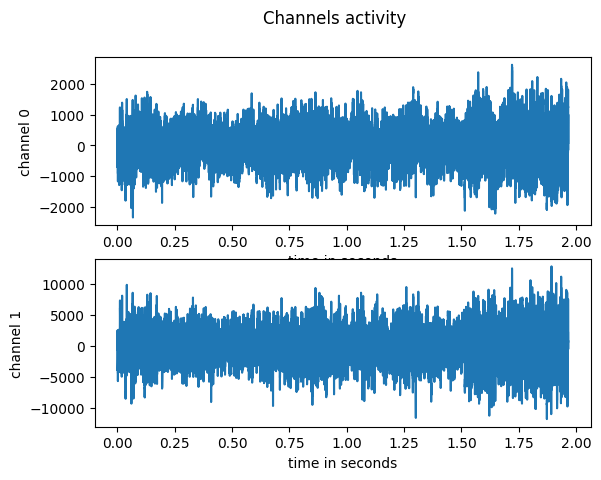

In [5]:
# plot signals
time = np.array( range( np.size(signals,0) ) )/antenna.sampling_frequency
fig, axs = plt.subplots( antenna.channels_number )
fig.suptitle('Channels activity')	
for s in range( antenna.channels_number ):
    axs[s].plot( time, signals[:,s] )
    axs[s].set( xlabel='time in seconds', ylabel='channel %d' % s )

plt.show()

## Saving signals as wav file
Since wavfiles are audio files, you cannot save more than 2 channels.

In [ ]:
import wave

WAV_FILENAME = 'toto.wav'

# 2 seconds run, getting signals from MEMs 1 and 2
antenna.run(
    mems = [1, 2],
    duration=10,
    frame_length=512,
    signal_q_size = 0,
)

with  wave.open( WAV_FILENAME, mode='wb' ) as wavfile:
    wavfile.setnchannels(2)
    wavfile.setsampwidth(2)
    wavfile.setframerate( antenna.sampling_frequency )

    # Get signals
    for data in antenna:
        signal = data >> 4
        wavfile.writeframesraw( np.int16( np.reshape( signal, np.size( signal ), order='F' ) ) )

# waiting for the end of the running thread is mandatory
antenna.wait()

## Hearing signal with *pyaudio* library

Note that `signal_q_size` is set to 0, setting the internal queue to an infinite length.
This prevents breaks in the audio stream.

In [ ]:
import pyaudio

FRAME_LENGTH = 512
SAMPLING_FREQUENCY = 50000
antenna.setSamplingFrequency( SAMPLING_FREQUENCY )

# Instantiate PyAudio and initialize PortAudio system resources (1)
p = pyaudio.PyAudio()

# Open stream
stream = p.open(
    format = pyaudio.paFloat32,
    channels = 2,
    rate = int( antenna.sampling_frequency ),
    output=True,
    frames_per_buffer=FRAME_LENGTH,
)

# Start running the remote Megamicros system
antenna.run( 
    mems=[17, 18],
    duration=10,
    frame_length=FRAME_LENGTH,
    counter_skip = True,
    signal_q_size = 0
)

# Get signals
transfers_counter = 0
for data in antenna:
    signal = data >> 4

    # convert into float and normalize with MEMs sensibility
    data = ( data.astype( np.float32 ) * antenna.sensibility )

    # write into audio stream
    stream.write( data, num_frames=FRAME_LENGTH )
    transfers_counter += 1

# Close stream and release PortAudio system resources (5)
stream.close()            
p.terminate()

antenna.wait()


## Saving signals as H5 files

You can save signal in H5 file format. In this example sigansl are saved on the MBS remote server.
The antenna receive no more signals. 

In [ ]:
antenna.run(
    mems = [3, 4],
    duration=2,
    frame_length=512,
    h5_recording=True,                          # H5 recording ON
    h5_pass_through=True,                       # perform F5 recording on server
    h5_rootdir='./',                            # directory where to save file
    h5_compressing=False,                       # Use compression or not
    background_mode=True,
    signal_q_size = 0,
)

antenna.wait()

## Getting signals yourself

In this example, signals are received using the antenna internal queue.

In [ ]:
import queue

antenna.run(
    mems = [1, 2],
    duration=2,
    frame_length=512,
    signal_q_size = 0,
)

i = 0
while True:
    try:
        data = antenna.signal_q.get( timeout=5 )
        print( f"[{i}]" )
        i += 1
        # do what you want with data...

    except queue.Empty:
        print( f"exit from loop at i={i}" )
        break

antenna.wait()

## Listening to the Megamicro remote server
By starting a *master* run on the server, you can connect to the server from others hosts and listening to the signal stream.

### Staring the master run
This call lets the remote server starting a run in the background mode.

In [ ]:

antenna.run(
    mems = [0, 1, 2, 3, 4, 5, 6, 7],
    duration=0,
    frame_length=512,
    signal_q_size=0,
    job='master', 
)

2023-11-06 14:07:46,851 [INFO]:  .Starting run execution
2023-11-06 14:07:46,853 [INFO]:  .Install MemsArray settings
2023-11-06 14:07:46,854 [INFO]:  .8 MEMs were activated among 0 to 31 available MEMs
2023-11-06 14:07:46,854 [INFO]:  .Install MemsArrayWS settings
2023-11-06 14:07:46,855 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-11-06 14:07:46,855 [INFO]:  .Requested job: master
2023-11-06 14:07:46,856 [INFO]:  .Run infinite loop (duration=0)
2023-11-06 14:07:46,856 [INFO]:  .H5 recording off
2023-11-06 14:07:46,856 [INFO]:  .Start a `master` running job on remote server
2023-11-06 14:07:46,857 [INFO]:  .Background execution mode off
2023-11-06 14:07:46,857 [INFO]:  .Run thread execution started
2023-11-06 14:07:46,858 [INFO]:  .Connecting to remote host localhost:9002...


2023-11-06 14:07:46,860 [INFO]:  .Connected
2023-11-06 14:07:46,861 [INFO]:  .Send running job command (master)
2023-11-06 14:07:46,863 [INFO]:  .Master run command accepted by server
2023-11-06 14:07:48,868 [INFO]:  .Halt connection with server and exit


In [ ]:
# Define the antenna
try:
    listener = MemsArrayWS( HOST, port=PORT )
except Exception as e:
    print( f"Failed: {e}" )


2023-11-06 14:07:52,163 [INFO]:  .Install MemsArrayWS settings
2023-11-06 14:07:52,164 [INFO]:  .Created a new antenna
2023-11-06 14:07:52,165 [INFO]:  .Async event loop already running. Adding coroutine to the event loop...


2023-11-06 14:07:52,168 [INFO]:  .Try connecting to ws://localhost:9002...
2023-11-06 14:07:52,170 [INFO]:  .Received positive answer from server
2023-11-06 14:07:52,171 [INFO]:  .Getting settings values from remote receiver...
2023-11-06 14:07:52,171 [INFO]:  .Received settings from server [ok]
2023-11-06 14:07:52,172 [INFO]:  .Set 32 available MEMs numbered from 0 to 31
2023-11-06 14:07:52,172 [INFO]:  .No analogic channels available
2023-11-06 14:07:52,173 [INFO]:  .Starting MegamicrosWS device [ready]


Run a listener job. 
Please make attention to always specified the `job` value. Otherwise your next run will start with the old `job` value. 

Beware that if you start a listening job without a limited duration, then you have no way to stop it unless you create your own thread for that... 

In [8]:
listener.setFrameLength(512)
listener.run(
    mems = [0, 1],
    frame_length=512,
    signal_q_size=0,
    duration=10,
    job='listen'
)

# Init a np.ndarray
signals = np.ndarray( (0, listener.channels_number ) )

# Get signals
i = 0
for data in listener:
    i += 1
    signals = np.concatenate( ( signals, data ), axis=0 )

# waiting for the end of the running thread is mandatory
listener.wait()
print( f"Exit from loop. Received {i} frames. Signal shape is: {np.shape( signals )}" )

2023-11-06 14:07:54,924 [INFO]:  .Starting run execution
2023-11-06 14:07:54,925 [INFO]:  .Install MemsArray settings
2023-11-06 14:07:54,926 [INFO]:  .2 MEMs were activated among 0 to 31 available MEMs
2023-11-06 14:07:54,927 [INFO]:  .Install MemsArrayWS settings
2023-11-06 14:07:54,927 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-11-06 14:07:54,928 [INFO]:  .Counter was not set -> set to False
2023-11-06 14:07:54,928 [INFO]:  .Counter skipping not set -> set to False
2023-11-06 14:07:54,928 [INFO]:  .Status was not set -> set to False
2023-11-06 14:07:54,929 [INFO]:  .Requested job: listen
2023-11-06 14:07:54,929 [INFO]:  .Perform a 10s run loop
2023-11-06 14:07:54,930 [INFO]:  .H5 recording off
2023-11-06 14:07:54,930 [INFO]:  .Start a `listen` running job on remote server
2023-11-06 14:07:54,931 [INFO]:  .Background execution mode off
2023-11-06 14:07:54,931 [INFO]:  .Run thread execution started
2023-11-06 14:07:54,931 [INFO]:  .Starting iterations: will produce data a

Exit from loop. Received 977 frames. Signal shape is: (500224, 2)


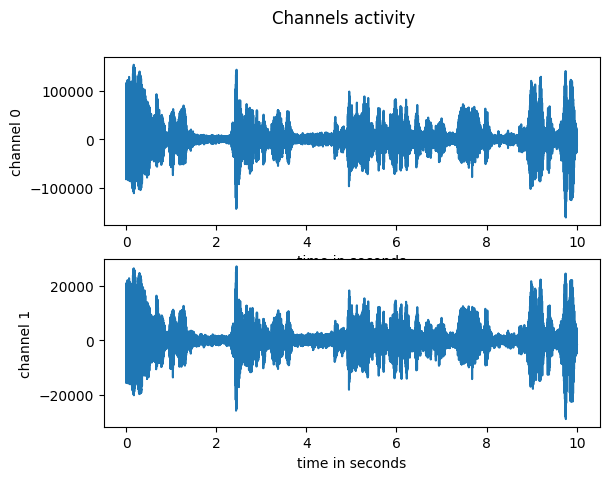

In [9]:
# plot signals
time = np.array( range( np.size(signals,0) ) )/listener.sampling_frequency
fig, axs = plt.subplots( listener.channels_number )
fig.suptitle('Channels activity')	
for s in range( listener.channels_number ):
    axs[s].plot( time, signals[:,s] )
    axs[s].set( xlabel='time in seconds', ylabel='channel %d' % s )

plt.show()

In [ ]:
# halt job
antenna.halt()

In [ ]:
# halt server
antenna.shutdown()

2023-11-06 14:08:26,262 [INFO]:  .Async event loop already running. Adding coroutine to the event loop...


2023-11-06 14:08:26,267 [INFO]:  .Connecting to remote host localhost:9002...
2023-11-06 14:08:26,269 [INFO]:  .Connected
2023-11-06 14:08:26,270 [INFO]:  .Send shutdown command to server
2023-11-06 14:08:26,271 [INFO]:  .Remote server shutdown success
